In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [6]:
train_path = "../data/chest_xray/train"
test_path = "../data/chest_xray/test"
val_path = "../data/chest_xray/val"

print("Paths set successfully!")

Paths set successfully!


In [8]:
import os

print(os.getcwd())

print(os.listdir("../data"))

c:\Users\Samee\Documents\MediLens_AI_Project\notebooks
['chest_xray', 'chest_xray.zip', 'diabetes', 'diabetes.zip']


In [9]:
import os

print(os.listdir("../data/chest_xray"))

['chest_xray']


In [10]:
train_path = "../data/chest_xray/chest_xray/train"
test_path = "../data/chest_xray/chest_xray/test"
val_path = "../data/chest_xray/chest_xray/val"

In [11]:
import os

print("Train:", os.path.exists(train_path))
print("Validation:", os.path.exists(val_path))
print("Test:", os.path.exists(test_path))

Train: True
Validation: True
Test: True


In [12]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

c:\Users\Samee\Documents\MediLens_AI_Project\venv311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 784s 5s/step - accuracy: 0.7993 - loss: 0.4178 - val_accuracy: 0.8750 - val_loss: 0.4539
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - accuracy: 0.8738 - loss: 0.2964 - val_accuracy: 0.6250 - val_loss: 0.6683
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 652s 4s/step - accuracy: 0.8859 - loss: 0.2790 - val_accuracy: 0.6250 - val_loss: 0.6975
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 650s 4s/step - accuracy: 0.8938 - loss: 0.2602 - val_accuracy: 0.8125 - val_loss: 0.7561
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9007 - loss: 0.2455 - val_accuracy: 0.8750 - val_loss: 0.5543


In [16]:
loss, accuracy = cnn.evaluate(test_generator)

print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8926 - loss: 0.2792
Test Accuracy: 0.8926281929016113


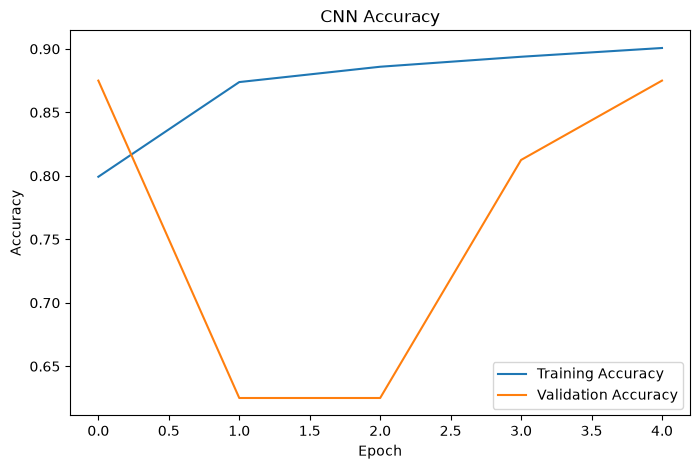

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Accuracy")

plt.legend()

plt.show()

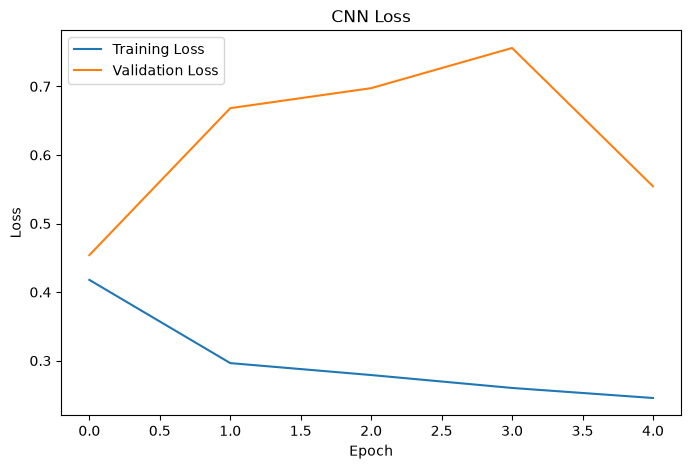

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Loss")

plt.legend()

plt.show()